> - # <b>导入数据</b>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('Mall_Customers.csv')
data.set_index('CustomerID', inplace = True)
display(data.head())

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19.0,18.0,39
2,Male,21.0,15.0,81
3,Female,20.0,NaN,6
4,Female,23.0,16.0,77
5,Female,31.0,17.0,40


> - # <b>可视化、观察异常值分布、查看缺失值、数据预处理</b>

In [12]:
display(data.isnull().sum())

Gender                    2
Age                       2
Annual Income (k$)        3
Spending Score (1-100)    0
dtype: int64

In [13]:
data.interpolate(method = 'pad', inplace = True)
display(data.isnull().sum())

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [14]:
display(data.describe())

,Age,Annual Income (k$),Spending Score (1-100)
count,202.000000,202.000000,202.000000
mean,38.683168,60.752475,50.262376
std,13.739532,26.812934,25.918653
min,18.000000,15.000000,1.000000
25%,29.000000,40.500000,34.250000
50%,36.000000,61.500000,50.000000
75%,48.750000,78.000000,73.000000
max,70.000000,137.000000,99.000000


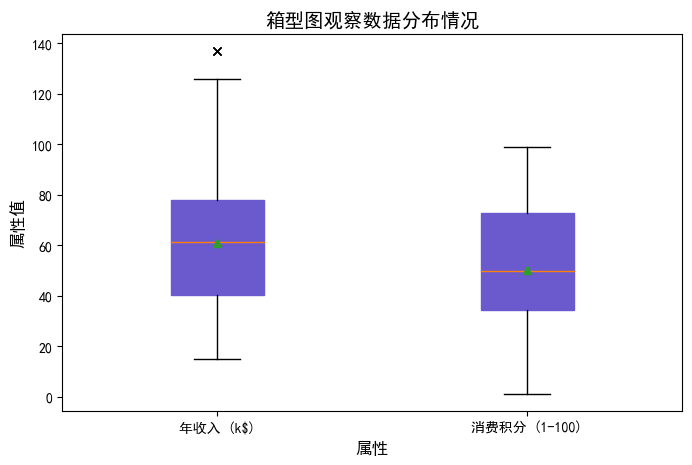

In [15]:
data.rename({'Annual Income (k$)': 'Annual_Income',
            'Spending Score (1-100)': 'Spending_Score'},
            axis='columns', inplace=True)

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize = (8, 5), dpi = 100)
ax.boxplot(data[['Annual_Income', 'Spending_Score']], labels = ['年收入 (k$)', '消费积分 (1-100)'], 
            widths = 0.3, patch_artist = True, showmeans = True, sym = 'x',
            boxprops = dict(color = 'slateblue', facecolor = 'slateblue'))

ax.set_title('箱型图观察数据分布情况', fontsize = 14)
ax.set_xlabel('属性', fontsize = 12)
ax.set_ylabel('属性值', fontsize = 12)
fig.show()

In [16]:
income_QU, income_IQR, income_QL = [data['Annual_Income'].quantile(x*0.25) for x in range(1, 4)]
score_QU, score_IQR, score_QL = [data['Spending_Score'].quantile(x*0.25) for x in range(1, 4)]

data[(income_QL - 1.5*income_IQR > data['Annual_Income']) | 
    (data['Annual_Income'] > income_QU + 1.5*income_IQR)] = data['Annual_Income'].mean()
data[(score_QL - 1.5*score_IQR > data['Spending_Score']) | 
    (data['Spending_Score'] > score_QU + 1.5*score_IQR)] = data['Spending_Score'].mean()

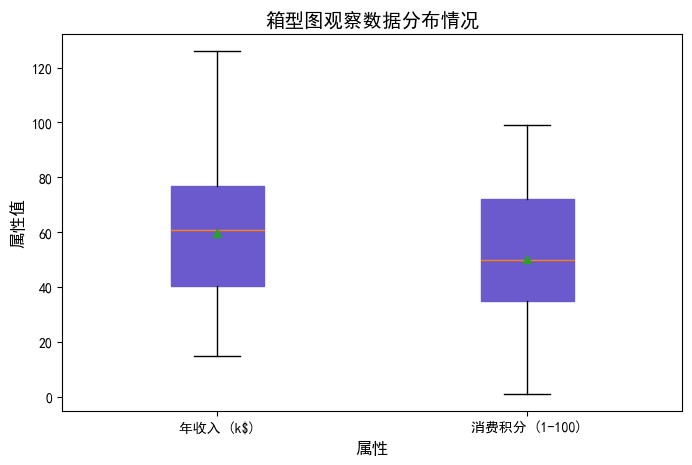

In [17]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
ax.boxplot(data[['Annual_Income', 'Spending_Score']], labels=['年收入 (k$)', '消费积分 (1-100)'],
           widths=0.3, patch_artist=True, showmeans=True, sym='x',
           boxprops=dict(color='slateblue', facecolor='slateblue'))

ax.set_title('箱型图观察数据分布情况', fontsize=14)
ax.set_xlabel('属性', fontsize=12)
ax.set_ylabel('属性值', fontsize=12)
fig.show()

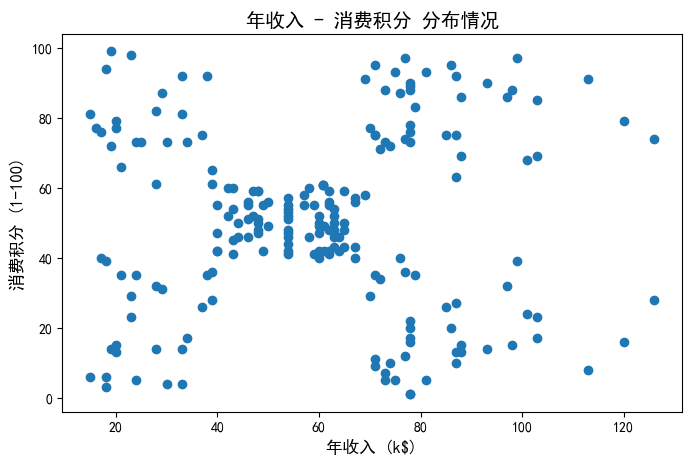

In [19]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
ax.scatter(data['Annual_Income'], data['Spending_Score'], marker='o')
ax.set_title('年收入 - 消费积分 分布情况', fontsize=14)
ax.set_xlabel('年收入 (k$)', fontsize=12)
ax.set_ylabel('消费积分 (1-100)', fontsize=12)
fig.show()

> - # <b>数据标准化</b>

In [20]:
from sklearn.preprocessing import StandardScaler

# 只提取对实验有关的属性
X = data[['Annual_Income', 'Spending_Score']]
X = StandardScaler().fit_transform(X)
display(X[:20, :])

array([[-1.66115264, -0.43943853],
       [-1.78088949,  1.20565106],
       [-1.78088949, -1.73200893],
       [-1.74097721,  1.04897586],
       [-1.70106493, -0.40026973],
       [-1.70106493,  1.00980706],
       [-1.66115264, -1.73200893],
       [-1.66115264,  1.71484546],
       [-1.66115264, -1.84951533],
       [-1.62124036,  0.85313186],
       [-1.62124036, -1.41865853],
       [-1.62124036,  1.91068946],
       [-1.58132808, -1.37948973],
       [-1.58132808,  1.04897586],
       [-1.58132808, -1.45782733],
       [-1.58132808,  1.12731346],
       [-1.5414158 , -0.59611373],
       [-1.5414158 ,  0.61811906],
       [-1.46159123, -0.83112653],
       [-1.46159123,  1.87152066]])

> - # <b>观察不同簇的聚类效果</b>

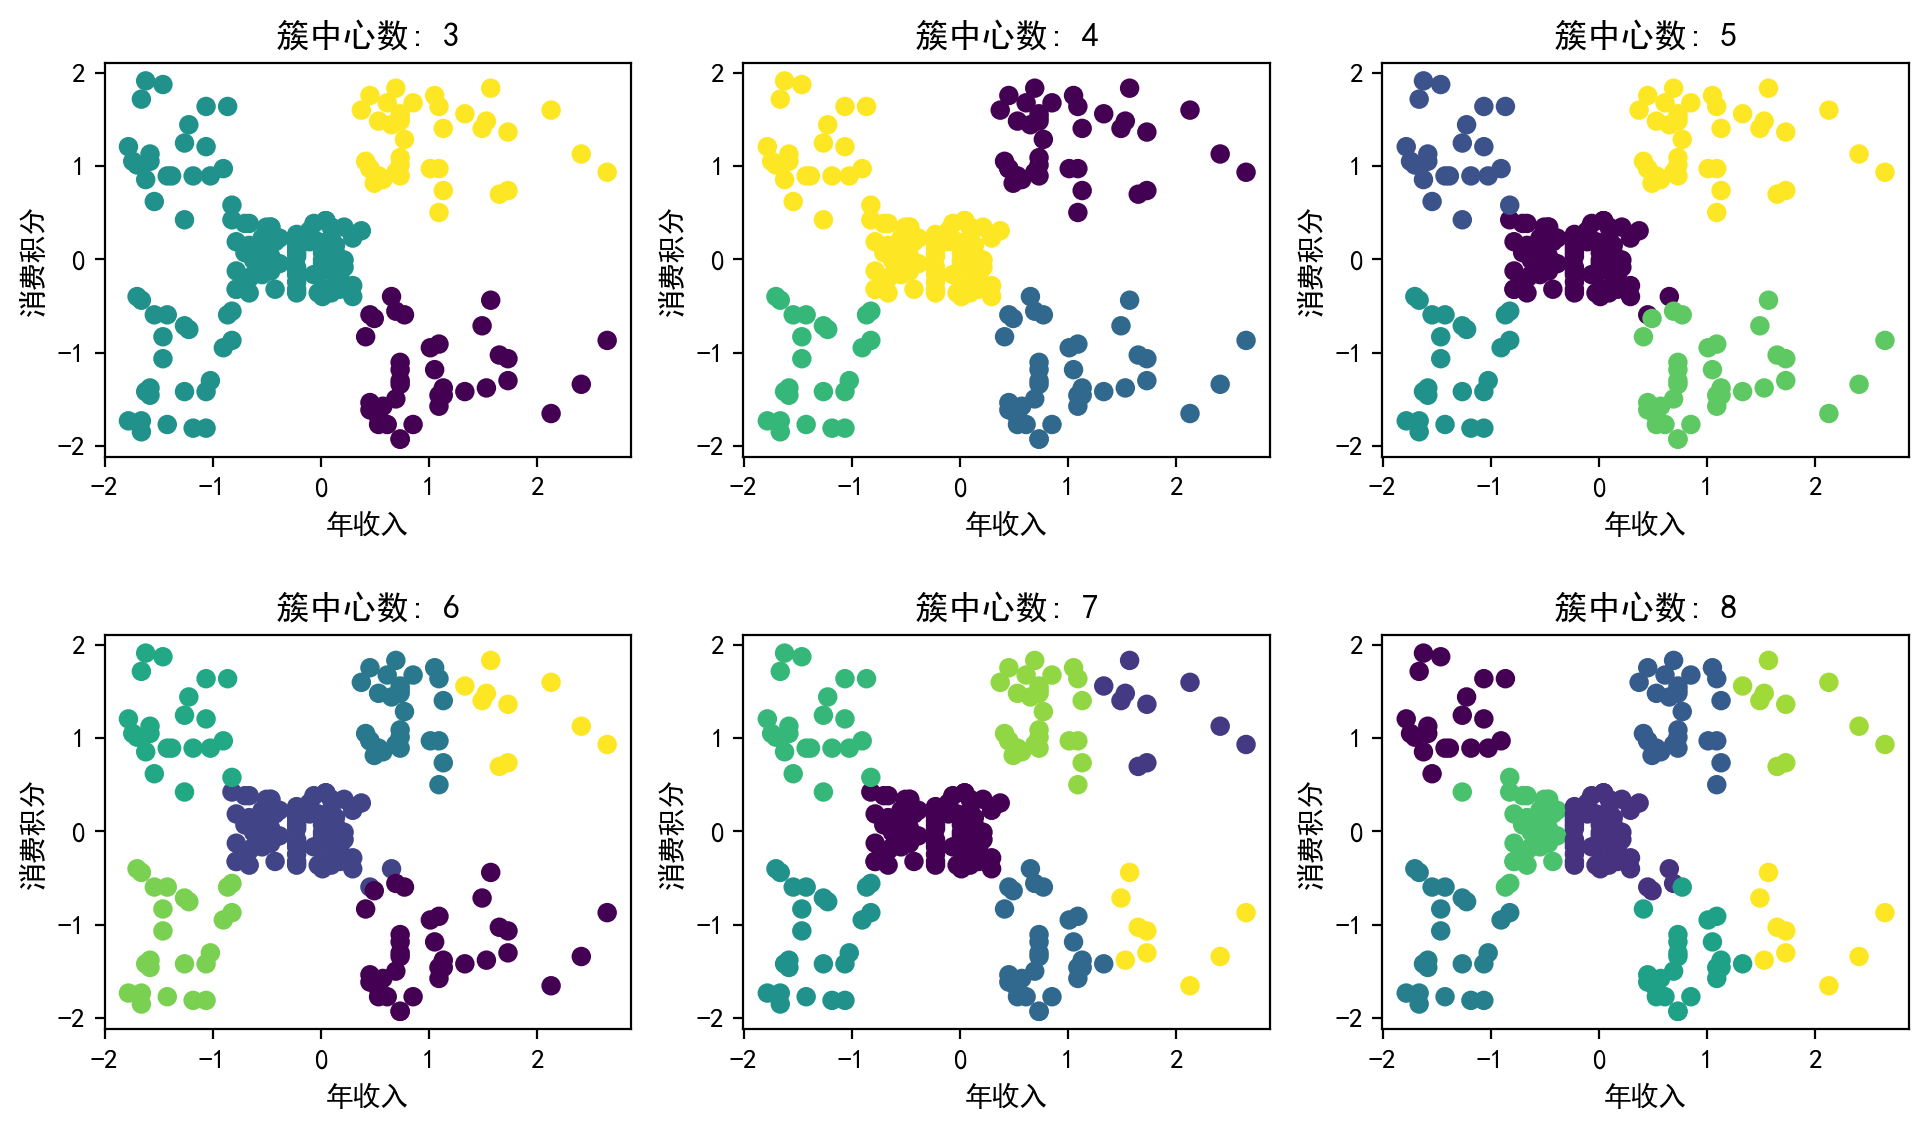

In [21]:
from sklearn.cluster import KMeans

wcs = list()
subgraph = ((x, y) for x in range(0, 2) for y in range(0, 3))
fig, ax = plt.subplots(2, 3, figsize = (10, 6), dpi = 200)

for k in range(3, 9):
    model = KMeans(n_clusters = k)
    model.fit(X)
    wcs.append(model.inertia_)
    x, y = next(subgraph)
    ax[x, y].scatter(X[:, 0], X[:, 1], c = model.labels_, marker = 'o')
    ax[x, y].set_title(f'簇中心数: {k}')
    ax[x, y].set_xlabel('年收入')
    ax[x, y].set_ylabel('消费积分')

fig.tight_layout(pad=2, w_pad=1, h_pad=2) # 控制子图之间的间距
fig.show()

> - # <b>肘部法选择k值</b>

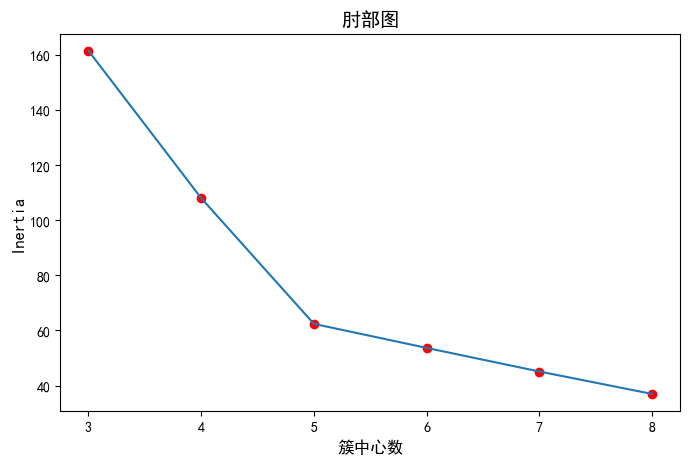

In [22]:
fig, ax = plt.subplots(figsize = (8, 5), dpi = 100)
ax.plot(range(3, 9), wcs)
ax.scatter(range(3, 9), wcs, marker = 'o', c = 'r')
plt.title('肘部图', fontsize = 14)
plt.xlabel('簇中心数', fontsize = 12)
plt.ylabel('Inertia', fontsize = 12)
fig.show()

> - # <b>选择k值为5的K-Means模型进行聚类</b>

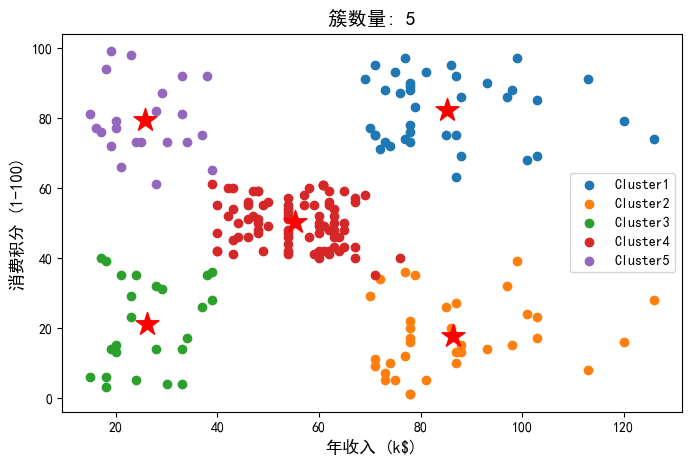

In [23]:
X = data[['Annual_Income', 'Spending_Score']].values
model = KMeans(n_clusters = 5)
y_pred = model.fit_predict(X)

fig, ax = plt.subplots(figsize = (8, 5), dpi = 100)
[ax.scatter(X[y_pred == x, 0], X[y_pred == x, 1], label = f'Cluster{x+1}') for x in range(5)]
ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker='*', s=300, c='r')
ax.set_title('簇数量: 5', fontsize = 14)
ax.set_xlabel('年收入 (k$)', fontsize = 12)
ax.set_ylabel('消费积分 (1-100)', fontsize = 12)
ax.legend(loc = 'best')
fig.show()

> - # <b>分析不同年龄下的消费积分总和</b>

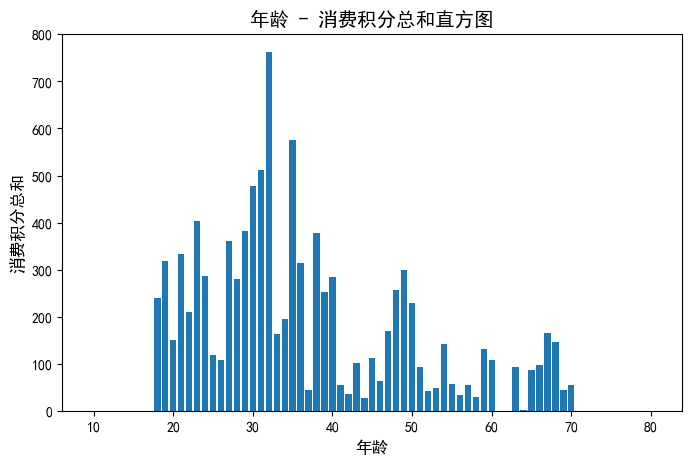

In [24]:
scores = [data[data['Age'] == x]['Spending_Score'].sum() for x in range(10, 81)]

fig, ax = plt.subplots(figsize = (8, 5), dpi = 100)
ax.bar(range(10, 81), scores)
ax.set_title('年龄 - 消费积分总和直方图', fontsize = 14)
ax.set_xlabel('年龄', fontsize = 12)
ax.set_ylabel('消费积分总和', fontsize = 12)
fig.show()

> - # <b>分析各年龄段消费积分占比</b>

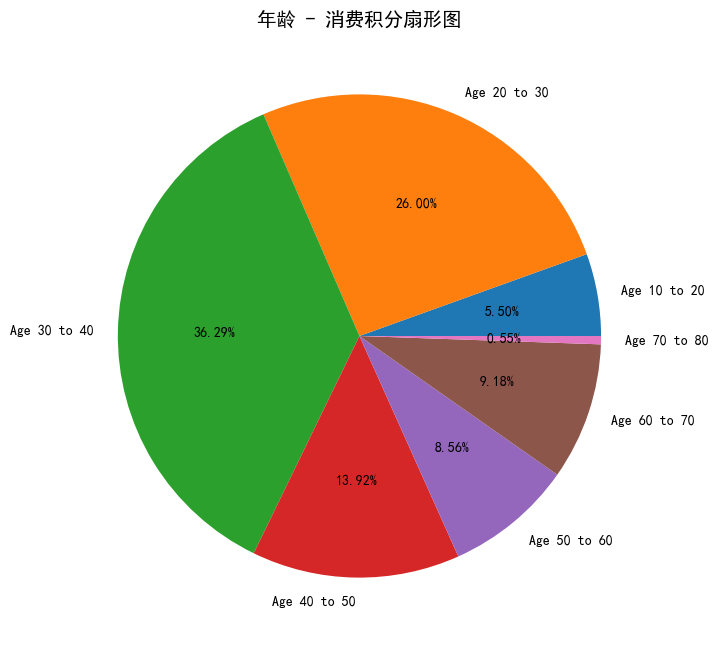

In [25]:
scores = [data[(x*10 <= data['Age']) & (data['Age'] < x*10+10)]['Spending_Score'].sum() for x in range(1, 8)]
labels = [f'Age {x*10} to {x*10+10}' for x in range(1, 8)]

fig, ax = plt.subplots(figsize = (8, 8), dpi = 100)
ax.pie(scores, labels = labels, autopct='%.2f%%')
ax.set_title('年龄 - 消费积分扇形图', fontsize=14)
fig.show()

> - # <b>分析不同性别在各年龄下的消费积分总和</b>

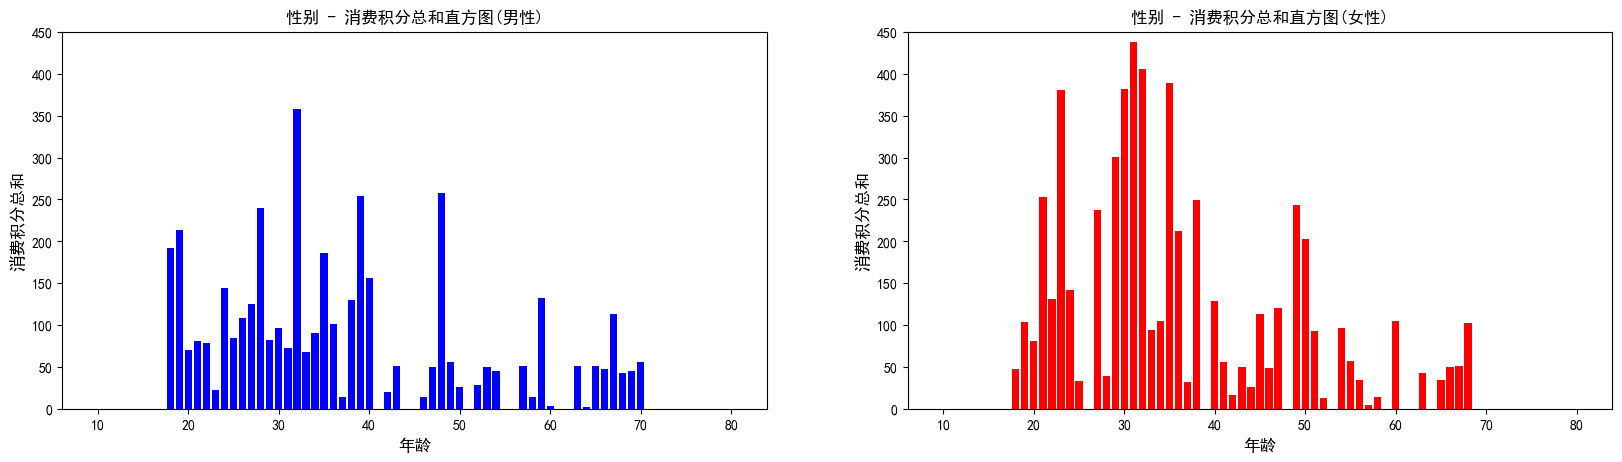

In [26]:
scores_male = [data[(data['Age'] == x) & (data['Gender'] == 'Male')]['Spending_Score'].sum() for x in range(10, 81)]
scores_female = [data[(data['Age'] == x) & (data['Gender'] == 'Female')]['Spending_Score'].sum() for x in range(10, 81)]

fig, ax = plt.subplots(1, 2, figsize = (20, 5), dpi = 100)
ax[0].bar(range(10, 81), scores_male, color = 'b')
ax[0].set_ylim(0, 450)
ax[0].set_title('性别 - 消费积分总和直方图(男性)', fontsize = 12)
ax[0].set_xlabel('年龄', fontsize = 12)
ax[0].set_ylabel('消费积分总和', fontsize = 12)

ax[1].bar(range(10, 81), scores_female, color = 'r')
ax[1].set_ylim(0, 450)
ax[1].set_title('性别 - 消费积分总和直方图(女性)', fontsize = 12)
ax[1].set_xlabel('年龄', fontsize = 12)
ax[1].set_ylabel('消费积分总和', fontsize = 12)
fig.show()

> - # <b>分析不同性别的消费积分总和占比</b>

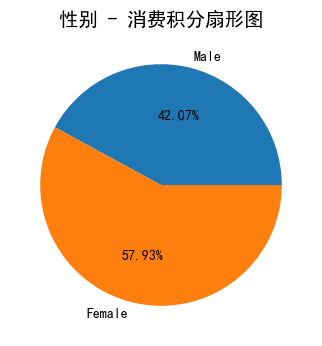

In [27]:
scores_male = data[data['Gender'] == 'Male']['Spending_Score'].sum()
scores_female = data[data['Gender'] == 'Female']['Spending_Score'].sum()

fig, ax = plt.subplots(figsize = (4, 4), dpi = 100)
ax.pie([scores_male, scores_female], labels = ['Male', 'Female'], autopct='%.2f%%')
ax.set_title('性别 - 消费积分扇形图', fontsize=14)
fig.show()

> - # <b>模型评估</b>

In [28]:
from sklearn import metrics

temp_d = data[['Annual_Income', 'Spending_Score']]
y_pred = model.predict(temp_d)

# SSE
print(f'SSE:\t{model.inertia_}')

# SC
print(f'SC:\t{metrics.silhouette_score(temp_d, y_pred)}')

# CH
print(f'CH:\t{metrics.calinski_harabasz_score(temp_d, y_pred)}')

# Cluster_centers
centers = pd.DataFrame(model.cluster_centers_, columns = ['x', 'y'])
centers.index.name = 'Class'
display(centers)

SSE:	39787.13788529491
SC:	0.560936983682748
CH:	270.69464387959397


,x,y
Class,,
0,85.210526,82.105263
1,86.342857,17.571429
2,26.166667,21.000000
3,55.292258,50.111535
4,25.727273,79.363636


> - # <b>选择合适的聚类模型再聚类(重新选择了DBSCAN、层次聚类算法)</b>

> DBSCAN

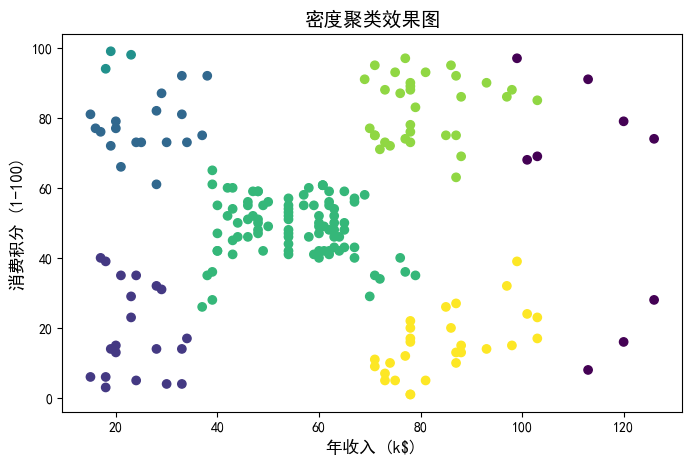

In [29]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps = 9, min_samples = 3).fit(data[['Annual_Income', 'Spending_Score']])

fig, ax = plt.subplots(figsize = (8, 5), dpi = 100)
ax.scatter(data['Annual_Income'], data['Spending_Score'], c = db.labels_)
ax.set_title('密度聚类效果图', fontsize=14)
ax.set_xlabel('年收入 (k$)', fontsize=12)
ax.set_ylabel('消费积分 (1-100)', fontsize=12)
fig.show()

> 模型评估

In [30]:
temp_d = data[['Annual_Income', 'Spending_Score']]
y_pred = db.fit_predict(temp_d)
print(f'SC:\t{metrics.silhouette_score(temp_d, y_pred)}')
print(f'CH:\t{metrics.calinski_harabasz_score(temp_d, y_pred)}')

SC:	0.4957554955617851
CH:	173.3000481033071


> 层次聚类

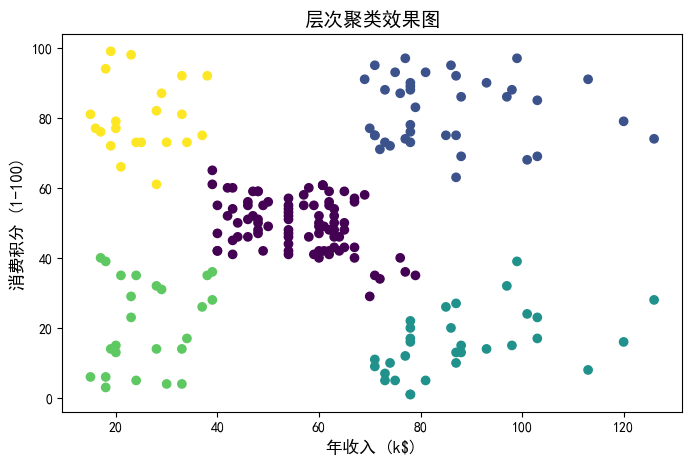

In [31]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(distance_threshold = 200, n_clusters = None)
clustering = clustering.fit(data[['Annual_Income', 'Spending_Score']])

fig, ax = plt.subplots(figsize = (8, 5), dpi = 100)
ax.scatter(data['Annual_Income'], data['Spending_Score'], c = clustering.labels_)
ax.set_title('层次聚类效果图', fontsize = 14)
ax.set_xlabel('年收入 (k$)', fontsize = 12)
ax.set_ylabel('消费积分 (1-100)', fontsize = 12)
fig.show()

> 模型评估

In [32]:
temp_d = data[['Annual_Income', 'Spending_Score']]
y_pred = clustering.fit_predict(temp_d)
print(f'SC:\t{metrics.silhouette_score(temp_d, y_pred)}')
print(f'CH:\t{metrics.calinski_harabasz_score(temp_d, y_pred)}')

SC:	0.5593540857824281
CH:	264.27362057655006
